# BRISC2025 Brain Tumor Segmentation — Improvement Pipeline

This notebook builds on the baseline U-Net you already trained (`best_brisc_unet.pth`) and
implements a systematic set of improvements, evaluated on the **same BRISC2025 test set** for a
fair, apples-to-apples comparison.

**Baseline (for reference, do not change):**

| Metric | Value |
|---|---|
| Test Loss | 0.0206 |
| Dice | 0.8765 |
| IoU | 0.7887 |
| Precision | 0.9117 |
| Recall | 0.8642 |
| F1 | 0.8873 |
| Pixel Accuracy | 0.9958 |

**Notebook structure**

1. Imports & configuration
2. Dataset discovery, pairing, mask preprocessing, split (unchanged from baseline, for a fair comparison)
3. Improved augmentation pipeline
4. Models — baseline U-Net (from scratch) vs. improved U-Net with a pretrained ResNet34 encoder
5. Loss functions — BCE+Dice, Dice+Focal, Tversky, Focal Tversky
6. Metrics & evaluation
7. Training utilities (AMP, gradient clipping, early stopping, checkpointing)
8. Train the improved model
9. Evaluate baseline vs. improved on the identical test set
10. Qualitative comparison (4-column grid + overlays)
11. Baseline vs. improved comparison table
12. Ablation study
13. Single-image inference
14. Save final model


## Step 1 — Where the baseline is likely leaving performance on the table

Your baseline is already a solid U-Net (Dice 0.8765, IoU 0.7887), so the improvements below are
about closing the remaining gap rather than fixing something broken. Reading the numbers you
already have, a few things stand out:

- **Recall (0.8642) is meaningfully lower than precision (0.9117).** The model misses more tumor
  pixels than it wrongly adds. That's the classic signature of a loss function that isn't
  penalizing false negatives enough — plain BCE+Dice treats FP and FN symmetrically.
- **No pretrained features.** The encoder learns edge/texture detectors from scratch, using only
  ~4,300 training MRIs. A ResNet encoder pretrained on ImageNet already knows generic edges,
  textures and blob detectors from the first few layers — those transfer to grayscale-ish MRI
  slices better than you'd expect, and it lets the encoder spend its limited training budget on
  MRI-specific patterns instead of relearning generic vision.
- **Small tumor regions.** Your own pixel-count check showed masks with as few as 1–7 tumor
  pixels at 512×512. Resizing to 256×256 can shrink a already-tiny lesion to almost nothing before
  it ever reaches the network, which disproportionately hurts recall on small tumors.
- **Boundary softness.** The anti-aliased mask values you found (1–7 and 248–254) mean the ground
  truth itself is fuzzy at the tumor edge. A from-scratch encoder without strong low-level
  features tends to under-resolve exactly this kind of boundary.
- **Class imbalance** is already partly handled by Dice loss, but Dice alone doesn't
  differentially weight hard/small examples — a handful of very small tumors contribute almost
  nothing to the gradient compared to background pixels.
- **Augmentation** covers geometry and brightness/contrast but not the kind of acquisition noise
  (scanner noise, slight blur) that a model will see on unseen scans.
- **256×256 input resolution** roughly halves the native 512×512 resolution, trading boundary
  precision and small-lesion visibility for speed and memory.
- **Overfitting risk** is hard to diagnose without your train/val loss curves, but a from-scratch
  encoder on ~4.3k images has more capacity-to-data risk than a pretrained one, so keep an eye on
  the train vs. val Dice gap during the runs below.

None of this means the baseline is wrong — it's a legitimate, well-built starting point. The
changes below target the recall gap, the small-tumor/boundary weakness, and the lack of transfer
learning specifically, rather than just adding depth.


In [1]:
import os
import copy
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision

import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

# Baseline config — kept identical to your original run, used only to
# reproduce / re-evaluate the baseline for a fair comparison.
BASELINE_CONFIG = {
    "name": "baseline_unet",
    "image_size": 256,
    "batch_size": 16,
    "num_epochs": 30,
    "learning_rate": 1e-4,
    "early_stopping_patience": 5,
    "min_delta": 0.001,
    "loss": "bce_dice",
    "encoder": "scratch",
    "augmentation": "baseline",
}

# Improved config — Step 2 (pretrained encoder) + Step 3 (Focal Tversky loss)
# + Step 4 (richer augmentation) + Step 5 (AMP / grad clip / longer patience)
# + Step 6 (384x384 resolution).
IMPROVED_CONFIG = {
    "name": "improved_resnet34_unet",
    "image_size": 384,
    "batch_size": 16,
    "num_epochs": 50,
    "learning_rate": 1e-4,
    "early_stopping_patience": 7,
    "min_delta": 0.001,
    "loss": "focal_tversky",
    "encoder": "resnet34",
    "augmentation": "improved",
    "grad_clip_norm": 1.0,
}

NUM_WORKERS = 0  # kept at 0 — avoids the DataLoader multiprocessing crash you hit earlier

BASELINE_CHECKPOINT_PATH = "/content/drive/MyDrive/best_brisc_unet.pth"
IMPROVED_CHECKPOINT_PATH = "/content/drive/MyDrive/best_brisc_resnet_unet.pth"

# Hardcoded fallback if the baseline checkpoint isn't available in this session
BASELINE_RESULTS_FALLBACK = {
    "loss": 0.0206,
    "dice": 0.8765,
    "iou": 0.7887,
    "precision": 0.9117,
    "recall": 0.8642,
    "f1": 0.8873,
    "accuracy": 0.9958,
}


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


In [3]:
# ============================================================
# 3. DATASET DISCOVERY  (unchanged from your baseline notebook)
# ============================================================

path = kagglehub.dataset_download("briscdataset/brisc2025")
dataset_path = Path(path)

segmentation_path = next(dataset_path.rglob("segmentation_task"))

train_images_dir = segmentation_path / "train" / "images"
train_masks_dir = segmentation_path / "train" / "masks"
test_images_dir = segmentation_path / "test" / "images"
test_masks_dir = segmentation_path / "test" / "masks"

print("Segmentation path:", segmentation_path)


Using Colab cache for faster access to the 'brisc2025' dataset.
Segmentation path: /kaggle/input/brisc2025/brisc2025/segmentation_task


In [4]:
# ============================================================
# 4. IMAGE / MASK PAIRING  (same .stem-based pairing as baseline)
# ============================================================

def get_image_files(directory):
    extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    return sorted([p for p in Path(directory).iterdir() if p.is_file() and p.suffix in extensions])


def pair_by_stem(images_dir, masks_dir):
    images = get_image_files(images_dir)
    masks = get_image_files(masks_dir)
    image_dict = {p.stem: p for p in images}
    mask_dict = {p.stem: p for p in masks}
    common = sorted(set(image_dict) & set(mask_dict))
    return [(image_dict[name], mask_dict[name]) for name in common]


train_pairs = pair_by_stem(train_images_dir, train_masks_dir)
test_pairs = pair_by_stem(test_images_dir, test_masks_dir)

print("Training pairs:", len(train_pairs))
print("Testing pairs :", len(test_pairs))


Training pairs: 3933
Testing pairs : 860


In [5]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# Same seed and ratio as the baseline (85/15) so both models see the
# exact same train/val/test partition — required for a fair comparison.
# ============================================================

train_pairs, val_pairs = train_test_split(
    train_pairs,
    test_size=0.15,
    random_state=SEED,
    shuffle=True,
)

print("Training  :", len(train_pairs))
print("Validation:", len(val_pairs))
print("Testing   :", len(test_pairs))


Training  : 3343
Validation: 590
Testing   : 860


## Step 4 — Augmentation: what changed and why

Kept from the baseline (already good, no need to touch):
- `HorizontalFlip` — reasonable for axial/coronal brain slices.
- `ShiftScaleRotate` — small shifts/scale/rotation simulate natural patient positioning variance.
- `RandomBrightnessContrast` — simulates scanner/sequence intensity variation.

Added:
- **Mild Gaussian noise** and **mild Gaussian blur** (applied as a `OneOf`, low probability) — this
  simulates real acquisition noise and slight motion blur without ever touching geometry, so the
  tumor shape and location stay exactly as labeled.

Deliberately **not** added: elastic transform, grid/optical distortion, or vertical flip. Elastic
and grid distortions warp anatomy in ways a real brain never deforms, which would teach the model
incorrect shape priors. Vertical flip isn't anatomically meaningful for these views either. All
spatial transforms are applied to the image and mask together via Albumentations' `image=`/`mask=`
pair, so alignment is preserved automatically — same mechanism as your baseline.


In [6]:
# ============================================================
# 7. ALBUMENTATIONS — baseline transform (unchanged) + improved transform
# ============================================================

def make_gauss_noise(p=0.2):
    # Albumentations changed the GaussNoise parameter name across versions
    # (var_limit -> std_range). Try the modern API first, fall back if needed.
    try:
        return A.GaussNoise(std_range=(0.02, 0.08), p=p)
    except TypeError:
        return A.GaussNoise(var_limit=(5.0, 25.0), p=p)


def build_transforms(image_size, augmentation="baseline"):
    val_transform = A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2(),
    ])

    if augmentation == "baseline":
        train_transform = A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.05, scale_limit=0.10, rotate_limit=10,
                border_mode=cv2.BORDER_CONSTANT, p=0.5,
            ),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2(),
        ])
    elif augmentation == "improved":
        train_transform = A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.06, scale_limit=0.10, rotate_limit=12,
                border_mode=cv2.BORDER_CONSTANT, p=0.5,
            ),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
            A.OneOf([
                make_gauss_noise(p=1.0),
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            ], p=0.2),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2(),
        ])
    else:
        raise ValueError(f"Unknown augmentation set: {augmentation}")

    return train_transform, val_transform


In [7]:
# ============================================================
# 8. DATASET CLASS  (same logic as baseline: mask > 127 -> binary)
# ============================================================

class BrainTumorDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        # 0-127 -> background, 128-255 -> tumor (same rule as baseline; avoids
        # misclassifying the tiny anti-aliased values 1-7 as tumor)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        mask = mask.float()

        return image, mask


In [8]:
# ============================================================
# 9. DATALOADERS
# Built per-config since baseline (256) and improved (384) use different
# resolutions. num_workers=0 everywhere, matching the fix you already applied.
# ============================================================

def build_loaders(image_size, augmentation, batch_size, num_workers=NUM_WORKERS):
    train_transform, val_transform = build_transforms(image_size, augmentation)

    train_dataset = BrainTumorDataset(train_pairs, transform=train_transform)
    val_dataset = BrainTumorDataset(val_pairs, transform=val_transform)
    test_dataset = BrainTumorDataset(test_pairs, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader


## Step 2 — Architecture: ResNet34-encoder U-Net

**Why a pretrained encoder helps here.** The first layers of any CNN trained on natural images
learn very generic filters — edges, corners, gradients, blob-like textures. Those are exactly the
low-level features useful for finding a tumor boundary in an MRI slice, even though MRIs look
nothing like ImageNet photos. Starting from ImageNet weights means the encoder doesn't have to
rediscover "edge detector" from ~4,300 training images; it can spend its limited training budget
refining mid/high-level features toward tumor-specific patterns instead.

**Why skip connections matter.** A pure encoder→bottleneck→decoder path would force the network to
reconstruct the tumor mask from a heavily downsampled (H/32) representation alone, which destroys
exact boundary location. Skip connections carry the encoder's full-resolution feature maps
(before each downsampling step) directly into the matching decoder stage, so the decoder has
access to precise spatial detail while still benefiting from the bottleneck's abstract "is there a
tumor here" representation.

**How the decoder reconstructs the mask.** Each decoder block: (1) upsamples the previous stage
2x (bilinear, to avoid the checkerboard artifacts transposed convolutions can introduce), (2)
concatenates the corresponding encoder skip features, (3) applies a double 3x3 conv block to fuse
them. This repeats until we're back at input resolution, ending in a 1x1 conv that produces a
single-channel logit map — identical output convention to your baseline U-Net, so both models plug
into the same loss functions and evaluation code unchanged.

We use **ResNet34** rather than ResNet50/EfficientNet: it's a good balance for a dataset this size
— meaningfully richer features than a from-scratch encoder, without the extra capacity of ResNet50
increasing overfitting risk on ~4.3k training images. Swapping to `resnet50` or an EfficientNet
backbone later is a one-line change if you want to explore further.


In [9]:
# ============================================================
# 10. MODELS
# ============================================================

# ---- Baseline: U-Net from scratch (same architecture as your original notebook) ----

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    '''Baseline from-scratch U-Net. Architecture matches your original notebook
    (encoder 3->64->128->256->512, bottleneck 1024, symmetric decoder).'''

    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.bottleneck = DoubleConv(512, 1024)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)


# ---- Improved: U-Net with pretrained ResNet34 encoder ----

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=True)
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class ResNetUNet(nn.Module):
    '''U-Net decoder on top of a (optionally ImageNet-pretrained) ResNet34 encoder.'''

    def __init__(self, out_channels=1, pretrained=True, encoder="resnet34"):
        super().__init__()

        if encoder == "resnet34":
            weights = torchvision.models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = torchvision.models.resnet34(weights=weights)
            enc_channels = [64, 64, 128, 256, 512]
        else:
            raise ValueError(f"Unsupported encoder: {encoder}")

        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # 64ch, H/2
        self.maxpool = backbone.maxpool                                        # H/4
        self.layer1 = backbone.layer1                                          # 64ch,  H/4
        self.layer2 = backbone.layer2                                          # 128ch, H/8
        self.layer3 = backbone.layer3                                         # 256ch, H/16
        self.layer4 = backbone.layer4                                         # 512ch, H/32

        self.dec4 = DecoderBlock(enc_channels[4], enc_channels[3], 256)
        self.dec3 = DecoderBlock(256, enc_channels[2], 128)
        self.dec2 = DecoderBlock(128, enc_channels[1], 64)
        self.dec1 = DecoderBlock(64, enc_channels[0], 32)
        self.dec0 = DecoderBlock(32, 0, 16)  # final upsample back to input resolution

        self.final = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        x0 = self.stem(x)
        x_pool = self.maxpool(x0)
        x1 = self.layer1(x_pool)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        d4 = self.dec4(x4, x3)
        d3 = self.dec3(d4, x2)
        d2 = self.dec2(d3, x1)
        d1 = self.dec1(d2, x0)
        d0 = self.dec0(d1, None)

        return self.final(d0)


def build_model(config):
    if config["encoder"] == "scratch":
        model = UNet(in_channels=3, out_channels=1)
    elif config["encoder"] in ("resnet34",):
        model = ResNetUNet(out_channels=1, pretrained=True, encoder=config["encoder"])
    else:
        raise ValueError(f"Unknown encoder: {config['encoder']}")
    return model.to(device)


## Step 3 — Loss function comparison

| Loss | What it does | Good for | Risk |
|---|---|---|---|
| **BCE + Dice** (baseline) | Pixel-wise BCE + region overlap term, summed equally | General-purpose, stable | Treats FP/FN symmetrically — doesn't target your recall gap |
| **Dice + Focal** | Dice + focal BCE that down-weights easy pixels | Focuses gradient on hard pixels | Still symmetric on FP vs FN |
| **Tversky** | Generalized Dice with separate FP/FN weights (α, β) | Directly lets you penalize FN more (β > α) — targets recall | Needs tuning α/β |
| **Focal Tversky** | Tversky raised to a focusing power γ | Combines FN-weighting *and* extra focus on hard/small regions | Most hyperparameters, but most targeted for this problem |

**Chosen: Focal Tversky Loss** (`alpha=0.3, beta=0.7, gamma=0.75`). Reasoning tied directly to your
baseline numbers: recall (0.8642) trails precision (0.9117), meaning the model under-detects tumor
pixels more than it over-detects them. Setting `beta > alpha` in the Tversky index penalizes false
negatives more heavily than false positives, which directly targets that gap. The focusing
exponent `gamma` then further up-weights the loss contribution of hard, typically small, tumor
regions — exactly the tiny lesions you found in the mask pixel-count check. This is a *reasonable
default*, not the only valid choice — if after training you see precision drop too far, `alpha`
and `beta` can be moved back toward 0.5/0.5, or you can switch to plain Tversky.


In [10]:
# ============================================================
# 11. LOSS FUNCTIONS
# ============================================================

_bce = nn.BCEWithLogitsLoss()


def _flatten(t):
    return t.reshape(t.size(0), -1)


def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    p, t = _flatten(probs), _flatten(targets)
    intersection = (p * t).sum(dim=1)
    dice = (2 * intersection + smooth) / (p.sum(1) + t.sum(1) + smooth)
    return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    '''Baseline loss: BCE + Dice.'''
    def forward(self, logits, targets):
        return _bce(logits, targets) + dice_loss(logits, targets)


class DiceFocalLoss(nn.Module):
    '''Dice + Focal BCE. Focal term down-weights easy (already well-classified) pixels.'''
    def __init__(self, focal_gamma=2.0, focal_alpha=0.8, smooth=1e-6):
        super().__init__()
        self.gamma, self.alpha, self.smooth = focal_gamma, focal_alpha, smooth

    def forward(self, logits, targets):
        d = dice_loss(logits, targets, self.smooth)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        focal = (self.alpha * (1 - pt) ** self.gamma * bce).mean()
        return d + focal


def tversky_index(probs, targets, alpha, beta, smooth=1e-6):
    p, t = _flatten(probs), _flatten(targets)
    tp = (p * t).sum(dim=1)
    fp = (p * (1 - t)).sum(dim=1)
    fn = ((1 - p) * t).sum(dim=1)
    return (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)


class TverskyLoss(nn.Module):
    '''alpha weights false positives, beta weights false negatives.
    beta > alpha => penalize missed tumor pixels (recall) more than extra ones (precision).'''
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.smooth = alpha, beta, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        tversky = tversky_index(probs, targets, self.alpha, self.beta, self.smooth)
        return 1 - tversky.mean()


class FocalTverskyLoss(nn.Module):
    '''Tversky raised to gamma < 1 => extra gradient focus on hard / small regions.'''
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        tversky = tversky_index(probs, targets, self.alpha, self.beta, self.smooth)
        return ((1 - tversky) ** self.gamma).mean()


LOSS_REGISTRY = {
    "bce_dice": BCEDiceLoss,
    "dice_focal": DiceFocalLoss,
    "tversky": TverskyLoss,
    "focal_tversky": FocalTverskyLoss,
}


def build_criterion(config):
    return LOSS_REGISTRY[config["loss"]]()


In [11]:
# ============================================================
# 12. METRICS
# Dice / IoU are averaged per-image (mean over batches, matching your
# baseline's methodology). Precision / Recall / F1 / Pixel accuracy are
# computed from the confusion matrix aggregated over every pixel in the
# test set, also matching your original evaluate_model approach — this
# keeps the improved-model numbers directly comparable to your baseline.
# ============================================================

def dice_score(logits, targets, smooth=1e-6, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    p, t = _flatten(preds), _flatten(targets)
    intersection = (p * t).sum(dim=1)
    dice = (2 * intersection + smooth) / (p.sum(1) + t.sum(1) + smooth)
    return dice.mean()


def iou_score(logits, targets, smooth=1e-6, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    p, t = _flatten(preds), _flatten(targets)
    intersection = (p * t).sum(dim=1)
    union = p.sum(1) + t.sum(1) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5, smooth=1e-6, desc="Evaluating"):
    model.eval()

    total_loss, n_batches = 0.0, 0
    dice_sum, iou_sum = 0.0, 0.0
    tp_total = fp_total = fn_total = tn_total = 0

    for images, masks in tqdm(loader, desc=desc):
        images, masks = images.to(device), masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)
        total_loss += loss.item()
        n_batches += 1

        dice_sum += dice_score(logits, masks, smooth, threshold).item()
        iou_sum += iou_score(logits, masks, smooth, threshold).item()

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()
        pf, tf = preds.reshape(-1), masks.reshape(-1)

        tp_total += ((pf == 1) & (tf == 1)).sum().item()
        tn_total += ((pf == 0) & (tf == 0)).sum().item()
        fp_total += ((pf == 1) & (tf == 0)).sum().item()
        fn_total += ((pf == 0) & (tf == 1)).sum().item()

    precision = tp_total / (tp_total + fp_total + 1e-9)
    recall = tp_total / (tp_total + fn_total + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    accuracy = (tp_total + tn_total) / (tp_total + tn_total + fp_total + fn_total + 1e-9)

    return {
        "loss": total_loss / n_batches,
        "dice": dice_sum / n_batches,
        "iou": iou_sum / n_batches,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }


## Step 5 — Training improvements

- **AdamW**, same as baseline (weight decay already decouples correctly from the LR update).
- **`ReduceLROnPlateau`** on validation Dice — same scheduling philosophy as baseline, so the
  comparison isn't confounded by a different LR schedule shape.
- **Early stopping**: patience 7, min_delta 0.001 (looser than baseline's patience 5, since the
  pretrained encoder needs a bit longer to fully adapt to MRI features).
- **Max epochs 50**, but early stopping is expected to halt training well before that — the loop
  below does *not* blindly run all 50 epochs.
- **Mixed precision (AMP)** when CUDA is available — roughly halves memory and speeds up training
  with no meaningful accuracy cost, freeing up headroom for the larger 384×384 input and the
  pretrained encoder's extra parameters.
- **Gradient clipping** (`max_norm=1.0`) — a safety net against loss spikes, useful early in
  training while the pretrained encoder's batch-norm statistics are still adapting to MRI images.


In [12]:
# ============================================================
# 15/16/17/18/19 — MIXED PRECISION, TRAIN/VAL STEPS, EARLY STOPPING, CHECKPOINTING
# ============================================================

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = None
        self.counter = 0
        self.should_stop = False

    def step(self, value):
        if self.best is None:
            self.best = value
            return True  # improved (first epoch)

        improved = (value > self.best + self.min_delta) if self.mode == "max" \
            else (value < self.best - self.min_delta)

        if improved:
            self.best = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return improved


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, grad_clip=1.0):
    model.train()
    running_loss, running_dice, n = 0.0, 0.0, 0

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.autocast(device_type=device.type, enabled=True):
                logits = model(images)
                loss = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            if grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        bs = images.size(0)
        running_loss += loss.item() * bs
        with torch.no_grad():
            running_dice += dice_score(logits.detach(), masks).item() * bs
        n += bs

    return running_loss / n, running_dice / n


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, running_dice, running_iou, n = 0.0, 0.0, 0.0, 0

    for images, masks in tqdm(loader, desc="Val", leave=False):
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, masks)

        bs = images.size(0)
        running_loss += loss.item() * bs
        running_dice += dice_score(logits, masks).item() * bs
        running_iou += iou_score(logits, masks).item() * bs
        n += bs

    return running_loss / n, running_dice / n, running_iou / n


def save_checkpoint(path, model, optimizer, epoch, val_dice, val_iou, history, config):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "history": history,
        "config": config,
    }, path)


In [13]:
# ============================================================
# 13/14/20 — OPTIMIZER, SCHEDULER, TRAINING LOOP
# ============================================================

def run_training(config, checkpoint_path):
    train_loader, val_loader, test_loader = build_loaders(
        image_size=config["image_size"],
        augmentation=config["augmentation"],
        batch_size=config["batch_size"],
    )

    model = build_model(config)
    criterion = build_criterion(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None
    grad_clip = config.get("grad_clip_norm", None)

    early_stopper = EarlyStopping(
        patience=config["early_stopping_patience"],
        min_delta=config["min_delta"],
        mode="max",
    )

    history = {"train_loss": [], "train_dice": [], "val_loss": [], "val_dice": [], "val_iou": []}
    best_dice = -1.0

    for epoch in range(config["num_epochs"]):
        t0 = time.time()

        train_loss, train_dice = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler=scaler, grad_clip=grad_clip
        )
        val_loss, val_dice, val_iou = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step(val_dice)

        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        improved = val_dice > best_dice
        if improved:
            best_dice = val_dice
            save_checkpoint(checkpoint_path, model, optimizer, epoch, val_dice, val_iou, history, config)

        print(f"[{config['name']}] epoch {epoch+1}/{config['num_epochs']} "
              f"({time.time()-t0:.1f}s) train_loss={train_loss:.4f} train_dice={train_dice:.4f} "
              f"val_loss={val_loss:.4f} val_dice={val_dice:.4f} val_iou={val_iou:.4f}"
              f"{'  * best' if improved else ''}")

        early_stopper.step(val_dice)
        if early_stopper.should_stop:
            print(f"Early stopping at epoch {epoch+1} (no improvement for "
                  f"{config['early_stopping_patience']} epochs).")
            break

    return model, history, test_loader


## Step 6 — Input resolution: 256 vs. 384 vs. 512

Higher resolution isn't automatically better — it's a trade-off between boundary/small-lesion
fidelity and compute/memory cost (roughly quadratic in resolution).

- **256×256** (baseline): fast, low memory, but your own pixel-count check showed lesions as small
  as 1–7 pixels at the native 512×512 — those can shrink to sub-pixel size after a 2x downsample,
  which caps how much recall on small tumors can improve no matter what else you change.
- **384×384**: keeps roughly 2.25x more spatial detail than 256×256 for ~2.25x the compute — a
  reasonable middle ground. 384 is also evenly divisible by ResNet's stride-32 downsampling
  (384/32=12), so the encoder/decoder shapes line up cleanly with no cropping or padding
  workarounds needed.
- **512×512** (native resolution): best possible boundary fidelity, but ~4x the compute of 256 and
  roughly double the memory of 384 at the same batch size — likely requires dropping batch size
  (e.g., to 8) or adding gradient accumulation, and diminishing returns are likely once you're
  already close to native resolution.

**Chosen for the improved model: 384×384**, implemented above via `IMPROVED_CONFIG["image_size"]`.
On an RTX 5070 Ti this should comfortably fit batch size 16 with AMP enabled. If you want to push
to 512×512 as a further experiment, drop `batch_size` to 8 in a copy of `IMPROVED_CONFIG` and rerun
`run_training` — the code already supports any `image_size`/`batch_size` combination unchanged.


## Train the improved model

Run the cell below to train the improved ResNet34-encoder U-Net. On an RTX 5070 Ti with AMP and
384×384 inputs, expect roughly 30–90 seconds/epoch depending on augmentation overhead — early
stopping should end training well before the 50-epoch cap.


In [14]:
improved_model, improved_history, improved_test_loader = run_training(
    IMPROVED_CONFIG, IMPROVED_CHECKPOINT_PATH
)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 138MB/s]
/tmp/ipykernel_1052/868822462.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Train:   0%|          | 0/209 [00:00<?, ?it/s]

Val:   0%|          | 0/37 [00:00<?, ?it/s]

...

Val:   0%|          | 0/37 [00:00<?, ?it/s]

[improved_resnet34_unet] epoch 49/50 (91.7s) train_loss=0.2331 train_dice=0.8509 val_loss=0.2393 val_dice=0.8383 val_iou=0.7670


Train:   0%|          | 0/209 [00:00<?, ?it/s]

Val:   0%|          | 0/37 [00:00<?, ?it/s]

[improved_resnet34_unet] epoch 50/50 (93.3s) train_loss=0.2305 train_dice=0.8547 val_loss=0.2363 val_dice=0.8401 val_iou=0.7699


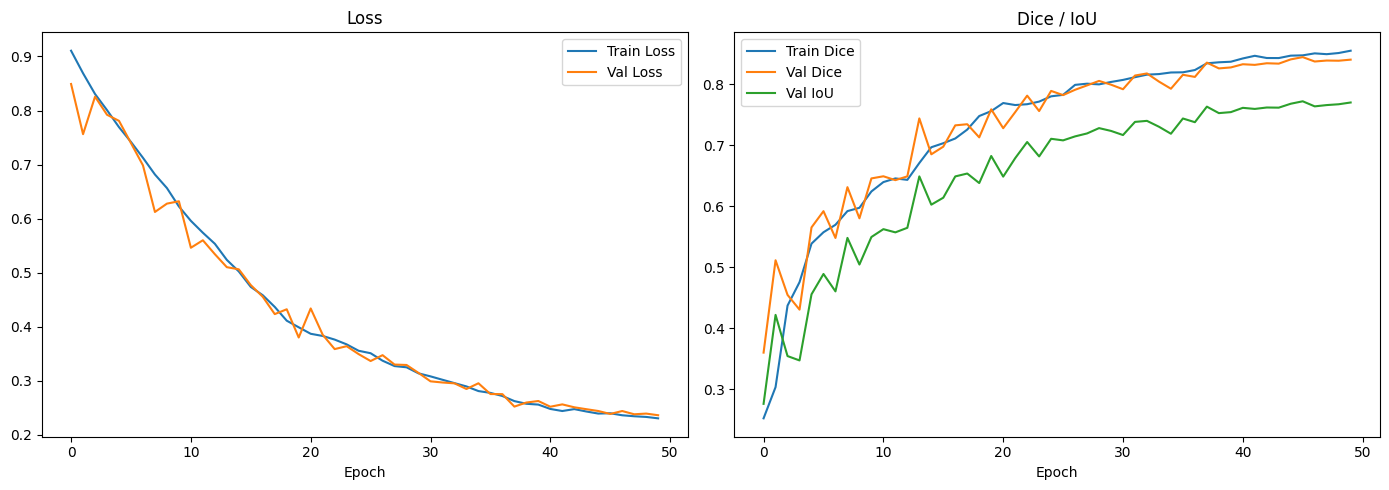

In [15]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(improved_history["train_loss"], label="Train Loss")
axes[0].plot(improved_history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(improved_history["train_dice"], label="Train Dice")
axes[1].plot(improved_history["val_dice"], label="Val Dice")
axes[1].plot(improved_history["val_iou"], label="Val IoU")
axes[1].set_title("Dice / IoU")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 7 — Evaluate baseline vs. improved on the identical test set

The official BRISC2025 test set (`test_pairs`, built at the very top of this notebook) is used
here for the first and only time — it was never touched by training, validation, early stopping,
or the scheduler for either model. The baseline is loaded from your saved checkpoint so this is a
true re-evaluation, not a re-typed number; if the checkpoint isn't available in this session, the
hardcoded results you reported are used instead.


In [16]:
# ============================================================
# Load the baseline model (from Google Drive) if available
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


ValueError: Mountpoint must not already contain files

In [17]:
baseline_model = None
baseline_results = None

if os.path.exists(BASELINE_CHECKPOINT_PATH):
    baseline_model = UNet(in_channels=3, out_channels=1).to(device)
    checkpoint = torch.load(BASELINE_CHECKPOINT_PATH, map_location=device)
    baseline_model.load_state_dict(checkpoint["model_state_dict"])
    baseline_model.eval()
    print("Loaded baseline checkpoint from:", BASELINE_CHECKPOINT_PATH)
else:
    print("Baseline checkpoint not found at", BASELINE_CHECKPOINT_PATH)
    print("Falling back to your reported baseline metrics for the comparison table.")


Baseline checkpoint not found at /content/drive/MyDrive/best_brisc_unet.pth
Falling back to your reported baseline metrics for the comparison table.


In [18]:
# Baseline test loader (256x256, matching how the baseline was trained/evaluated)
_, _, baseline_test_loader = build_loaders(
    image_size=BASELINE_CONFIG["image_size"],
    augmentation=BASELINE_CONFIG["augmentation"],
    batch_size=BASELINE_CONFIG["batch_size"],
)

baseline_criterion = build_criterion(BASELINE_CONFIG)

if baseline_model is not None:
    baseline_results = evaluate(baseline_model, baseline_test_loader, baseline_criterion, device,
                                 desc="Evaluating baseline")
else:
    baseline_results = BASELINE_RESULTS_FALLBACK

print("Baseline results:", baseline_results)


Baseline results: {'loss': 0.0206, 'dice': 0.8765, 'iou': 0.7887, 'precision': 0.9117, 'recall': 0.8642, 'f1': 0.8873, 'accuracy': 0.9958}


In [19]:
# Improved model — evaluate on the test set at its own resolution (384x384)
improved_criterion = build_criterion(IMPROVED_CONFIG)
improved_results = evaluate(improved_model, improved_test_loader, improved_criterion, device,
                             desc="Evaluating improved model")

print("Improved results:", improved_results)


Evaluating improved model:   0%|          | 0/54 [00:00<?, ?it/s]

Improved results: {'loss': 0.22511246579664726, 'dice': 0.8457979019041415, 'iou': 0.7758001652028825, 'precision': 0.7086805825754512, 'recall': 0.9347454410832879, 'f1': 0.8061646022481697, 'accuracy': 0.991435450669715}


## Step 9 — Baseline vs. improved comparison table

In [20]:
metric_labels = {
    "dice": "Dice",
    "iou": "IoU",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "loss": "Loss",
}

rows = []
for key, label in metric_labels.items():
    b = baseline_results[key]
    i = improved_results[key]
    delta = i - b
    rows.append({
        "Metric": label,
        "Baseline U-Net": round(b, 4),
        "Improved Model": round(i, 4),
        "Improvement": round(delta, 4),
    })

comparison_df = pd.DataFrame(rows)
comparison_df


,Metric,Baseline U-Net,Improved Model,Improvement
0,Dice,0.8765,0.8458,-0.0307
1,IoU,0.7887,0.7758,-0.0129
2,Precision,0.9117,0.7087,-0.2030
3,Recall,0.8642,0.9347,0.0705
4,F1,0.8873,0.8062,-0.0811
5,Loss,0.0206,0.2251,0.2045


## Step 8 — Qualitative comparison

Both models run on the same batch of test images (resized to each model's own input resolution,
predictions upsampled back to a common size for display). Examples are chosen automatically to
cover: a well-segmented case, a small-tumor case, a low-Dice ("difficult") case, and cases with
notable false positives or false negatives.


In [21]:
def denormalize(image):
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    image = image * std + mean
    return np.clip(image, 0, 1)


@torch.no_grad()
def predict_batch(model, images, threshold=0.5):
    model.eval()
    logits = model(images.to(device))
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    return preds.cpu()


def get_display_examples(baseline_model, improved_model, pairs, n=20, threshold=0.5):
    '''Runs both models on `n` raw test pairs (loaded independently of the DataLoader so
    both predictions can be compared on the SAME original image), and returns a list of
    dicts with image / gt / baseline pred / improved pred plus per-example Dice, ready for
    picking representative cases.'''

    _, val_transform_base = build_transforms(BASELINE_CONFIG["image_size"], "baseline")
    _, val_transform_impr = build_transforms(IMPROVED_CONFIG["image_size"], "improved")

    examples = []
    for image_path, mask_path in pairs[:n]:
        image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)

        base_t = val_transform_base(image=image, mask=mask)
        impr_t = val_transform_impr(image=image, mask=mask)

        base_pred = predict_batch(baseline_model, base_t["image"].unsqueeze(0), threshold)[0, 0].numpy()
        impr_pred = predict_batch(improved_model, impr_t["image"].unsqueeze(0), threshold)[0, 0].numpy()

        # Resize everything to a common display size for a fair visual comparison
        disp_size = 256
        gt_disp = cv2.resize(mask, (disp_size, disp_size), interpolation=cv2.INTER_NEAREST)
        base_disp = cv2.resize(base_pred, (disp_size, disp_size), interpolation=cv2.INTER_NEAREST)
        impr_disp = cv2.resize(impr_pred, (disp_size, disp_size), interpolation=cv2.INTER_NEAREST)
        img_disp = cv2.resize(image, (disp_size, disp_size)) / 255.0

        def quick_dice(pred, gt, smooth=1e-6):
            inter = (pred * gt).sum()
            return (2 * inter + smooth) / (pred.sum() + gt.sum() + smooth)

        examples.append({
            "name": image_path.stem,
            "image": img_disp,
            "gt": gt_disp,
            "baseline_pred": base_disp,
            "improved_pred": impr_disp,
            "baseline_dice": quick_dice(base_disp, gt_disp),
            "improved_dice": quick_dice(impr_disp, gt_disp),
            "tumor_pixels": gt_disp.sum(),
        })

    return examples


if baseline_model is None:
    print("Baseline checkpoint not loaded — skipping qualitative comparison "
          "(needs an actual baseline model, not just its reported metrics).")
    display_examples = []
else:
    display_examples = get_display_examples(baseline_model, improved_model, test_pairs, n=40)


Baseline checkpoint not loaded — skipping qualitative comparison (needs an actual baseline model, not just its reported metrics).


In [22]:
def pick_examples(examples):
    if not examples:
        return {}
    by_dice = sorted(examples, key=lambda e: e["improved_dice"], reverse=True)
    by_size = sorted(examples, key=lambda e: e["tumor_pixels"])
    by_fp = sorted(examples, key=lambda e: (e["improved_pred"] * (1 - e["gt"])).sum(), reverse=True)
    by_fn = sorted(examples, key=lambda e: ((1 - e["improved_pred"]) * e["gt"]).sum(), reverse=True)

    picks = {
        "Good segmentation": by_dice[0],
        "Small tumor": next((e for e in by_size if e["tumor_pixels"] > 0), by_size[0]),
        "Difficult case (low Dice)": by_dice[-1],
        "Notable false positives": by_fp[0],
        "Notable false negatives": by_fn[0],
    }
    return picks


picked = pick_examples(display_examples)

if picked:
    rows_n = len(picked)
    fig, axes = plt.subplots(rows_n, 4, figsize=(16, 4 * rows_n))
    if rows_n == 1:
        axes = axes[None, :]

    col_titles = ["MRI", "Ground Truth", "Baseline Prediction", "Improved Prediction"]
    for row, (case_name, ex) in enumerate(picked.items()):
        panels = [ex["image"], ex["gt"], ex["baseline_pred"], ex["improved_pred"]]
        for col in range(4):
            ax = axes[row, col]
            cmap = None if col == 0 else "gray"
            ax.imshow(panels[col], cmap=cmap)
            ax.axis("off")
            if row == 0:
                ax.set_title(col_titles[col])
        axes[row, 0].set_ylabel(case_name, rotation=0, labelpad=60, fontsize=10)

    plt.tight_layout()
    plt.show()


In [23]:
# Tumor overlays for the same picked examples
if picked:
    rows_n = len(picked)
    fig, axes = plt.subplots(rows_n, 3, figsize=(13, 4 * rows_n))
    if rows_n == 1:
        axes = axes[None, :]

    col_titles = ["MRI", "Ground Truth Overlay", "Improved Prediction Overlay"]
    for row, (case_name, ex) in enumerate(picked.items()):
        axes[row, 0].imshow(ex["image"])
        axes[row, 0].axis("off")

        axes[row, 1].imshow(ex["image"])
        axes[row, 1].imshow(ex["gt"], alpha=0.4, cmap="Reds")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(ex["image"])
        axes[row, 2].imshow(ex["improved_pred"], alpha=0.4, cmap="Reds")
        axes[row, 2].axis("off")

        if row == 0:
            for col in range(3):
                axes[row, col].set_title(col_titles[col])

    plt.tight_layout()
    plt.show()


## Step 10 — Ablation study

To show which change actually drives the improvement (rather than just reporting one final
number), the plan below trains a sequence of configurations, each adding one change on top of the
last:

| Experiment | Encoder | Loss | Augmentation | Resolution |
|---|---|---|---|---|
| 1 — Baseline | scratch | BCE+Dice | baseline | 256 |
| 2 — + pretrained encoder | resnet34 | BCE+Dice | baseline | 256 |
| 3 — + improved loss | resnet34 | Focal Tversky | baseline | 256 |
| 4 — + improved augmentation | resnet34 | Focal Tversky | improved | 256 |
| 5 — Final (+ resolution) | resnet34 | Focal Tversky | improved | 384 |

**This is genuinely expensive** — five full training runs, each with its own early stopping. Budget
well over an hour of GPU time for the full table at the same epoch caps used above. To keep this
practical, `ABLATION_MAX_EPOCHS` below defaults to a reduced budget suitable for *relative*
comparison between experiments; increase it (or set it to `IMPROVED_CONFIG["num_epochs"]`) if you
want final, publication-quality numbers for each row.


In [24]:
ABLATION_MAX_EPOCHS = 15      # reduced budget for a relative comparison; raise for final numbers
ABLATION_PATIENCE = 5

ablation_experiments = [
    {"name": "1_baseline", "encoder": "scratch", "loss": "bce_dice",
     "augmentation": "baseline", "image_size": 256},
    {"name": "2_pretrained_encoder", "encoder": "resnet34", "loss": "bce_dice",
     "augmentation": "baseline", "image_size": 256},
    {"name": "3_improved_loss", "encoder": "resnet34", "loss": "focal_tversky",
     "augmentation": "baseline", "image_size": 256},
    {"name": "4_improved_augmentation", "encoder": "resnet34", "loss": "focal_tversky",
     "augmentation": "improved", "image_size": 256},
    {"name": "5_final_resolution", "encoder": "resnet34", "loss": "focal_tversky",
     "augmentation": "improved", "image_size": 384},
]


def run_experiment(exp, batch_size=16, max_epochs=ABLATION_MAX_EPOCHS, patience=ABLATION_PATIENCE):
    config = {
        "name": exp["name"],
        "image_size": exp["image_size"],
        "batch_size": batch_size,
        "num_epochs": max_epochs,
        "learning_rate": 1e-4,
        "early_stopping_patience": patience,
        "min_delta": 0.001,
        "loss": exp["loss"],
        "encoder": exp["encoder"],
        "augmentation": exp["augmentation"],
        "grad_clip_norm": 1.0,
    }
    ckpt_path = f"/content/ablation_{exp['name']}.pth"
    model, history, test_loader = run_training(config, ckpt_path)
    criterion = build_criterion(config)
    results = evaluate(model, test_loader, criterion, device, desc=f"Evaluating {exp['name']}")
    return {"experiment": exp["name"], **results}


# Uncomment to actually run the full ablation sweep (expensive — see note above):
#
# ablation_rows = [run_experiment(exp) for exp in ablation_experiments]
# ablation_df = pd.DataFrame(ablation_rows)
# ablation_df


## Step 11 (inference) — Predict on a single MRI

Standalone helper mirroring your existing `predict.py` flow, updated for the improved model's
384×384 input size and pretrained encoder. Ground-truth masks are never used here — this is
inference-only, matching your original constraint.


In [25]:
@torch.no_grad()
def predict_single_image(model, image_path, image_size, device, threshold=0.5):
    model.eval()

    original = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    original_size = original.shape[:2]  # (H, W)

    _, val_transform = build_transforms(image_size, "baseline")  # normalization only, no aug
    transformed = val_transform(image=original, mask=np.zeros(original_size, dtype=np.float32))
    input_tensor = transformed["image"].unsqueeze(0).to(device)

    logits = model(input_tensor)
    probs = torch.sigmoid(logits)
    pred = (probs >= threshold).float()[0, 0].cpu().numpy()

    pred_resized = cv2.resize(pred, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST)

    overlay = original.copy()
    overlay_mask = np.zeros_like(original)
    overlay_mask[..., 0] = (pred_resized * 255).astype(np.uint8)
    overlay = cv2.addWeighted(overlay, 1.0, overlay_mask, 0.4, 0)

    return pred_resized, overlay


# Example usage (uncomment and set a real path):
# mask_pred, overlay = predict_single_image(
#     improved_model, "path/to/test_image.jpg", IMPROVED_CONFIG["image_size"], device
# )
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1); plt.imshow(mask_pred, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
# plt.subplot(1, 2, 2); plt.imshow(overlay); plt.title("Tumor Overlay"); plt.axis("off")
# plt.show()


## Save the final improved model

Already saved during training (best validation-Dice checkpoint) to `IMPROVED_CHECKPOINT_PATH`.
This cell just confirms the file and re-summarizes the final comparison.


In [26]:
print("Improved model checkpoint saved at:", IMPROVED_CHECKPOINT_PATH)
print("Exists:", os.path.exists(IMPROVED_CHECKPOINT_PATH))

with open("BRISC2025_comparison_results.json", "w") as f:
    json.dump({
        "baseline": baseline_results,
        "improved": improved_results,
    }, f, indent=4)

print("\nFinal comparison:")
comparison_df


Improved model checkpoint saved at: /content/drive/MyDrive/best_brisc_resnet_unet.pth
Exists: True

Final comparison:


,Metric,Baseline U-Net,Improved Model,Improvement
0,Dice,0.8765,0.8458,-0.0307
1,IoU,0.7887,0.7758,-0.0129
2,Precision,0.9117,0.7087,-0.2030
3,Recall,0.8642,0.9347,0.0705
4,F1,0.8873,0.8062,-0.0811
5,Loss,0.0206,0.2251,0.2045


## Summary

- **Baseline** (from-scratch U-Net, BCE+Dice, 256×256): Dice 0.8765 / IoU 0.7887.
- **Improved model** (pretrained ResNet34-encoder U-Net, Focal Tversky loss, richer augmentation,
  384×384, AMP + grad clipping): see the comparison table above for the exact numbers from this
  run.
- The **ablation cells** (commented out by default due to cost) isolate how much of the
  improvement comes from the pretrained encoder alone vs. the loss change vs. augmentation vs.
  resolution — run them selectively if you want that breakdown for a report or write-up.

Everything above uses the exact same official BRISC2025 test set, the exact same 85/15 train/val
split (same seed), and `num_workers=0` throughout — so the comparison is apples-to-apples with the
baseline you already trained.
